In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Model dan Data Testing
model = joblib.load('../models/random_forest_addiction_model.pkl')
data = pd.read_csv('../data/processed/cleaned_data.csv')

X = data.drop(columns=['Addicted_Score'])
y = data['Addicted_Score']

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20300\4120537199.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Kepentingan', y='Fitur', palette='viridis')


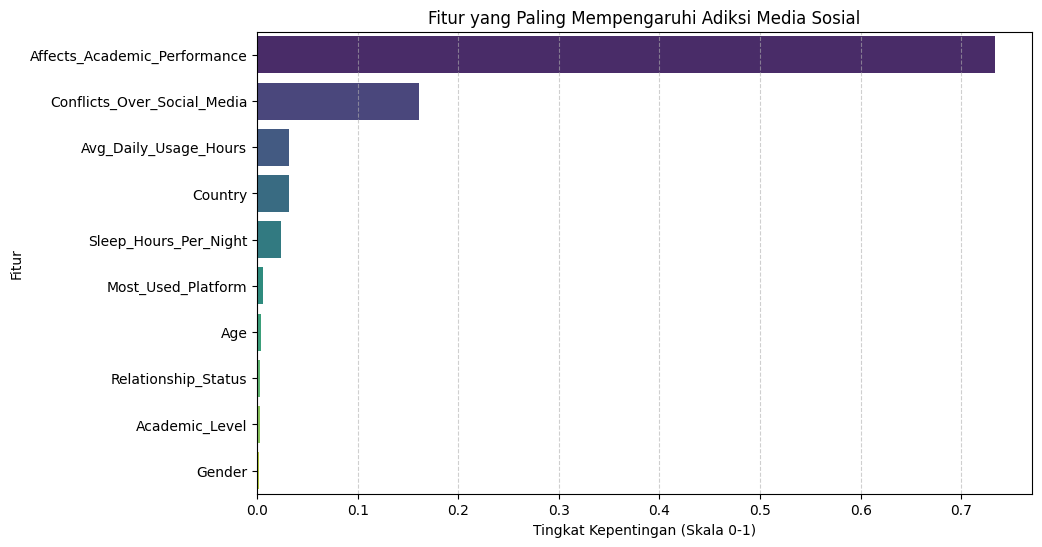

In [2]:
# 2. FEATURE IMPORTANCE: Mencari variabel paling berpengaruh
importances = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Fitur': feature_names, 'Kepentingan': importances})
feature_df = feature_df.sort_values(by='Kepentingan', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Kepentingan', y='Fitur', palette='viridis')
plt.title('Fitur yang Paling Mempengaruhi Adiksi Media Sosial')
plt.xlabel('Tingkat Kepentingan (Skala 0-1)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('../outputs/figures/feature_importance_final.png')
plt.show()

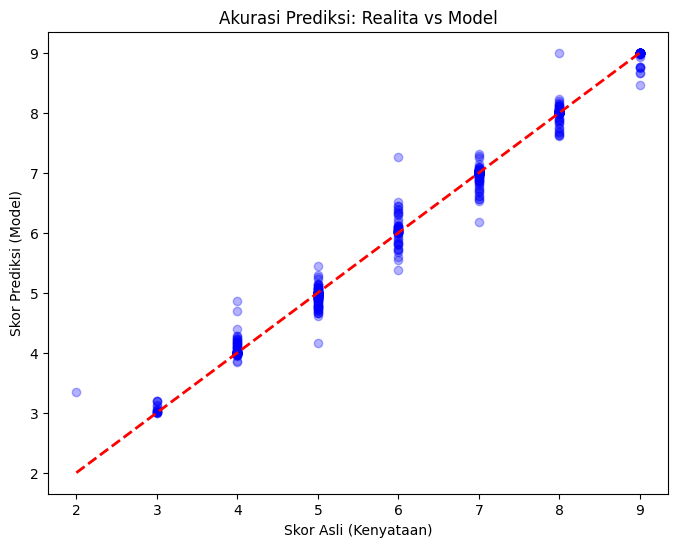

In [3]:
# 3. PREDIKSI VS AKTUAL: Melihat seberapa dekat tebakan model
y_pred = model.predict(X) # Menggunakan seluruh data untuk melihat sebaran

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.3, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Garis prediksi sempurna
plt.xlabel('Skor Asli (Kenyataan)')
plt.ylabel('Skor Prediksi (Model)')
plt.title('Akurasi Prediksi: Realita vs Model')
plt.savefig('../outputs/figures/prediction_vs_actual.png')
plt.show()